Problem understanding:

The company has a 100 millions USD to drill 200 oil wells. 
They provide a dataset with information of 10,000 productive oil wells for each region.
The main objective is to select the region that yields the highest mean profit within a risk of losing money below 2.5%.

Solution:
1. Traning a linear regression model for each region using a train-test split of 75:25 and check RMSE and R^2 to validate the model.
2. Using bootstrap method to estimate the mean profit distribution for each region and to simulate several oil well production scenarios.
3. Compare results to choose the best profitable region (asumming normal distribution the lowest/highest income will be computed as percentile 2.5% and 97.5% respectively)

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
def load_data(ruta_a_la_carpeta: str, nombre_del_archivo_csv: str) -> pd.DataFrame:
    ruta_completa = os.path.join(ruta_a_la_carpeta, nombre_del_archivo_csv)
    data = pd.read_csv(ruta_completa)
    return data

In [3]:
def split_data(data: pd.DataFrame, features_cols: list[str], target_col: str) -> dict[str, pd.DataFrame]:
    features = data[features_cols]
    target = data[target_col] # target es el volumen de reservas (miles de barriles)
    x_train, x_valid, y_train, y_valid = train_test_split(features, target, test_size=0.25, random_state = 12345)
    return {"x_train": x_train, "x_valid": x_valid, "y_train": y_train, "y_valid": y_valid}

In [4]:
def predict_production(data: dict[str, pd.DataFrame]) -> dict:
    
    model = LinearRegression()
    model.fit(data["x_train"], data["y_train"])
    y_predicted = model.predict(data["x_valid"])
    rmse = root_mean_squared_error(data["y_valid"], y_predicted)
    r2 = r2_score(data["y_valid"], y_predicted)
    y_predicted_mean = np.mean(y_predicted)
    
    return {
        "y_valid": data["y_valid"].reset_index(drop=True),
        "y_predicted": pd.Series(y_predicted).reset_index(drop=True),
        "y_predicted_mean": y_predicted_mean,
        "rmse": rmse,
        "r2": r2,
        "intercept": model.intercept_,
        "slope": model.coef_[0]
    }

Nota: 

Cada pozo cuesta aproximadamente 500k USD.

Cada barril se vende en 4500 USD.

Es decir que se requieren al menos 111.11 barriles para recuperar la inversión de un pozo.

In [5]:
def compute_top_200_profit(y_predicted: pd.Series, y_valid: pd.Series, total_cost: float = 100000000, sale_price: float = 4500) -> float:
    top_200_predicted = y_predicted.sort_values(ascending=False).head(200) #
    top_200_valid = y_valid.loc[top_200_predicted.index]
    income = sum(top_200_valid)*sale_price # earnings are computed using the actual production values.
    profit = income - total_cost
    return profit

***********REGION geo_data_0****************
Mean profit: 6007352.44
97.5% percentile profit: 12311636.06
2.5% percentile profit: 129483.31
Risk of loss: 2.00%
Model R2 score: 0.2799
Model RMSE: 37.5794
***************************************
 
***********REGION geo_data_1****************
Mean profit: 6652410.58
97.5% percentile profit: 11976415.87
2.5% percentile profit: 1579884.81
Risk of loss: 0.30%
Model R2 score: 0.9996
Model RMSE: 0.8931
***************************************
 
***********REGION geo_data_2****************
Mean profit: 6155597.23
97.5% percentile profit: 12306444.74
2.5% percentile profit: -122184.95
Risk of loss: 3.00%
Model R2 score: 0.2052
Model RMSE: 40.0297
***************************************
 


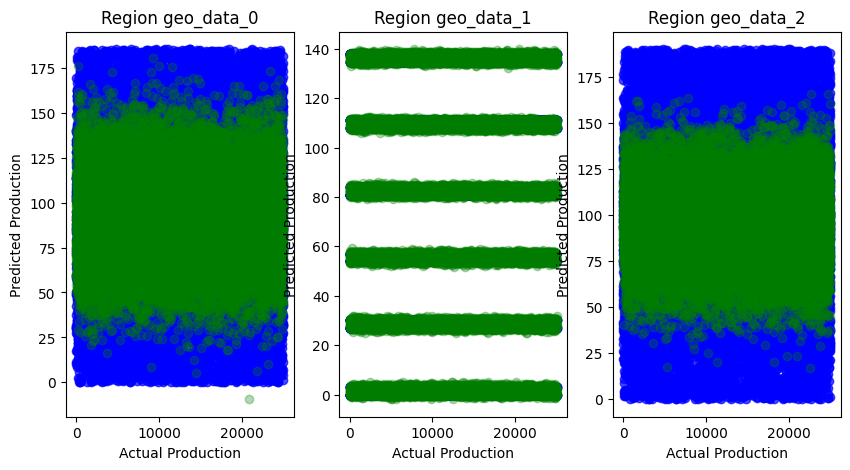

In [7]:
# Solution for all regions
output = {}

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

for i, file in enumerate(os.listdir("datasets")):
    region = file.split(".")[0]
    
    # Load data
    data = load_data("datasets",file)
    data_splitted = split_data(data = data, features_cols=["f0", "f1", "f2"], target_col="product")
    model_output = predict_production(data_splitted)

    profits = []
    df = pd.DataFrame({
        "y_valid": model_output["y_valid"],
        "y_predicted": model_output["y_predicted"]
    })   
    
    X = range(0,len(model_output["y_valid"]))
          
    ax[i].set_title(f"Region {region}")
    ax[i].scatter(X, model_output["y_valid"], alpha=0.7, label="Actual Production", color="blue")
    ax[i].scatter(X, model_output["y_predicted"], alpha=0.3, label="Predicted Production", color="green",)
    ax[i].set_xlabel("Actual Production")
    ax[i].set_ylabel("Predicted Production")
    
    state = np.random.RandomState(seed=12345)
    for iteration in range(1000):
        # Bootstrap sampling
        sample = df.sample(n=500, replace=True, random_state=state)
        y_valid_sample = sample["y_valid"]
        y_predicted_sample = sample["y_predicted"]
        profits.append(compute_top_200_profit(y_predicted_sample, y_valid_sample))

    output[region] = {
        "profits": profits,
        "mean_profit": np.mean(profits),
        "profit_97.5_percentile": np.percentile(profits, 97.5),
        "profit_2.5_percentile": np.percentile(profits, 2.5),
        "risk": (np.array(profits) < 0).sum() / len(profits), # add all wells with negative profit
        "model_r2_score": model_output["r2"],
        "model_rmse": model_output["rmse"],
        
    }
     
    print(f"***********REGION {region}****************")
    print(f"Mean profit: {output[region]['mean_profit']:.2f}")
    print(f"97.5% percentile profit: {output[region]['profit_97.5_percentile']:.2f}")
    print(f"2.5% percentile profit: {output[region]['profit_2.5_percentile']:.2f}")
    print(f"Risk of loss: {output[region]['risk']*100:.2f}%")
    print(f"Model R2 score: {output[region]['model_r2_score']:.4f}")
    print(f"Model RMSE: {output[region]['model_rmse']:.4f}")
    print("***************************************")
    print(" ")
    

Conclusions:

1. Oil well's production was obtained using a linear model. This model provided a way to simulate the drilling of oil wells in each region. 
2. Region GEO_DATA_0 R2 score was 0.27 (RMSE 37.57); this means that the model poorly predits the production of the region. Region GEO_DATA_1 scored 0.99 (RMSE 0.89) which is an excelent model adjustment to the production of the region. Finally, Region GEO_DATA_2 scored 0.20 (RMSE 40.02) which again is a poor prediction. 
3. Once obtained the simulation for a region, the top 200 productive wells of the simulationwere selected.
4. The real earnings were computed using real production for the wells corresponding to the selected index.
5. The bootstrap method using 1000 iteration was used to simulate a random selection of 500 wells in a region. By doing this, the reality of well drilling can be simulated: when drilling a well in a region, a random production will be obtain every time; so construction of several scenarios are needed in order to compute the mean profit and risk. Using that many iterations provides a solid empirical distribution of profit estimations
6. The results suggest that the best region for an invesment is Region GEO_DATA_1 with an average profit of ~6.6 Millions USD within a range of ~1.5 Millions USD and ~11.9 Millions USD (2.5% and 97% percentils; 95% confidence) and with an associated risk of lost ~0.3%
7. Region GEO_DATA_0 presents an average profit of ~6 Millions USD within a range of ~0.12 Millions USD and ~12.3 Millions USD (2.5% and 97% percentils; 95% confidence) and with an associated risk of lost ~2%.
8. The last region GEO_DATA_2 has a high risk of lost (~3%) and also the income is lower than the other two regions. It is recommended not to invest in this region.
9. Advices: It could be interesting to perform simulations during a price drop, so different scenarios are considered in decision making. 